# Assignment:4
1. you have to create one supervisor node.
2. create one router function
3. create three more node
3.1 llm call (llm node)
3.2 RAG (rag node)
3.3 web crawler(fetch the info in realtime from internet)
4. created one more node after this for validation for generated output --> explore the validation part how to do that
5. if validation going to be failed in that case again go to supervioser node and then supervisor node will again decide what needs to be call next
6. once the validation will pass then only generate the final output

In [10]:
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
import operator
from pydantic import BaseModel,Field
from typing import List
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate

In [34]:
filepath=r"C:\Users\hardi\OneDrive\Desktop\agentic ai assignments\Agentic-AI\England _ History, Map, Flag, Population, Cities, & Facts _ Britannica.pdf"
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader(filepath)
docs=loader.load()


In [38]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=10)
split_docs = text_splitter.split_documents(docs)

In [45]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")

c:\Users\hardi\OneDrive\Desktop\agentic ai assignments\Agentic-AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [46]:
len(embeddings.embed_query("hello world"))

384

In [48]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain.vectorstores import FAISS

index=faiss.IndexFlatL2(384)
vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

In [50]:
vector_store.add_documents(split_docs)

['896025e2-d02b-4ea5-8993-aeccefce8917',
 '530b3cb0-556d-4a7f-a904-0dcc422b8475',
 '77bd76e0-c6f6-48fc-8f4c-74ccd7a521c5',
 '81f2b722-0f51-46e1-af37-2991b08444de',
 '5a2edf19-24b5-4b7e-b512-83026944fd8e',
 'ae71e1b4-143f-4177-92e8-0b4ea9e770c2',
 '0e657549-1357-4abc-8a73-84be29fdc927',
 '6ae685e4-181b-4fb7-8805-fe4dbc2f600d',
 '29823e7d-cc2a-4408-8418-032fefe3bfb0',
 'bce8aedf-9b72-4fbb-82be-8e87025f6e62',
 '90d8b68c-0bf8-4c4e-8b61-06fd56cc7c04',
 'cc38fb9d-923e-491a-89b4-760b8efdb7cf',
 'cdabffa8-895d-4dde-8095-3f56b48dbb03',
 '3f3ef661-2f86-40a2-af9c-8529ecc46c0d',
 '256e68d4-51d9-48e8-8df0-a6f0bb729f9d',
 '8b3ade6a-cfe6-4502-88f3-58934b9f82bd',
 '5a488551-1917-4cc6-b0bb-46a877b252ac',
 '4cfda55d-a28c-46b9-816a-4592264cfbbe',
 'ee8950f2-f7f1-41a5-ac9b-de8d95c74c47',
 'bef60c11-f284-4b0e-aca4-b6966b8a838d',
 '7f25e4d1-70eb-4fc1-9bdf-fd93042de8e1',
 '48884646-980f-4295-a2e8-1910d1194580',
 'f305edb3-f8c1-4851-9399-ed2c3c6c13ce',
 'c3eec63f-877a-4448-bc3a-cef6b2232e6f',
 'b7003f9e-08ae-

In [ ]:
retriever=vector_store.as_retriever(search_kwargs={"k": 10})

In [222]:
class TopicSelection(BaseModel):
    Topic:str=Field(description="One of [england, wikipedia, Not Related]")
    Reason:str=Field(description="Reason for topic")
parser=PydanticOutputParser(pydantic_object=TopicSelection)

In [262]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    topic: str
    reason: str

In [263]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [264]:
from langchain_groq import ChatGroq

model="gemma2-9b-it"
llm=ChatGroq(model=model)


In [265]:
output=llm.invoke("hi")
print(output.content)

Hello! 👋  How can I help you today? 😄



In [266]:
def fun_1(state:AgentState):
    question=state["messages"][-1]
    print("Question:",question)
    template="""Your task is to clarify user from the given query into the following three categories:[england,wikipedia,Not Related]
    User:{question}
    {format_instructions}"""
    
    prompt=PromptTemplate(
        template=template,
        input_variables=["question"],
        partial_variables={"format_instructions":parser.get_format_instructions()}
    )
    
    chain=prompt|llm|parser
    response=chain.invoke({"question":question})
    print("Parsed Response:",response)
    return {
        "messages": state["messages"],
        "topic": response.Topic,   
        "reason": response.Reason
    }

In [267]:
state={"messages":["king of england?"]}
fun_1(state)

Question: king of england?
Parsed Response: Topic='england' Reason='The query directly asks about the king of England.'


{'messages': ['king of england?'],
 'topic': 'england',
 'reason': 'The query directly asks about the king of England.'}

In [286]:
def router(state:AgentState):
    print("-> Router ->")
    topic = state.get("topic", "").lower()
    question = state["messages"][-1].lower()
    print("Question:",question)
    if "england" in topic or "england" in question:
        return "RAG call"
    elif "wikipedia" in question:
        return "Wikipedia call"
    else:
        return "LLM call"



In [287]:
state={"messages":["king of england?"]}
router(state)

-> Router ->
Question: king of england?


'RAG call'

In [270]:
def fun_2(state:AgentState):
    print("-> LLM call ->")
    question=state["messages"][0]

    query= "Answer the following question with knowledge of the real world. Answer the following question:"+ question
    response=llm.invoke(query)
    return {"messages":[response.content]}

In [271]:
state={"messages":["hi"]}
fun_2(state)

-> LLM call ->


{'messages': ['Hello! 👋 \n\nHow can I help you today? 😊  \n']}

In [272]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [291]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
def fun_3(state:AgentState):
    print("-> RAG call ->")
    question=state["messages"][0]

    prompt = ChatPromptTemplate(
    [
        ("system", "You are a helpful AI bot that provides the info from the extracted text.Describe Briefly. If you don't know the answer, just say that you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
    )
    retriever=vector_store.as_retriever(search_kwargs={"k": 10})
    rag_chain= (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}|
    prompt|
    llm|
    StrOutputParser()
    )
    result=rag_chain.invoke(question)
    print(result)
    


In [292]:
state={"messages":["What is british isles?"]}
fun_3(state)

-> RAG call ->
The British Isles is made up of the island of Great Britain (England, Scotland, and Wales) and the island of Ireland. 



In [298]:
state={"messages":["synonyms of england?"]}
fun_3(state)

-> RAG call ->
According to the text provided, outside the British Isles, England is often mistakenly thought to be the same as **Britain**. 



In [302]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

def fun_4(state:AgentState):
    print("-> Wikipedia call ->")
    question=state["messages"][0]

    wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    response=wikipedia.run(question)
    print(response)
    

In [217]:
state={"messages":["who is diljit dosanjh?"]}
fun_4(state)

-> Wikipedia call ->


{'messages': ["Page: Diljit Dosanjh\nSummary: Diljit Dosanjh (born 6 January 1984) is an Indian singer, actor and film producer who works  in Punjabi and Hindi cinema. Dosanjh entered the Social 50 chart by Billboard in 2020. He has been featured in various music charts, including the Canadian Albums Chart, the UK Asian chart by Official Charts Company and the New Zealand Hot Singles. His films, including Jatt & Juliet 2, Sajjan Singh Rangroot, Honsla Rakh and Jatt & Juliet 3 are among the highest grossing Punjabi films in history.\nHailing from Dosanjh Kalan, Jalandhar district, Dosanjh began his career in 2002 and gained recognition in Punjabi music with his albums Smile (2005) and Chocolate (2008), followed by the blockbuster album; The Next Level (2009) with Yo Yo Honey Singh. He had a cameo in the Punjabi movie Mel Karade Rabba in 2010 and began to pursue acting, debuting as a leading actor in the Punjabi movie The Lion of Punjab in 2011.\nHe made his Bollywood debut in 2016 with 

In [304]:
from langgraph.graph import StateGraph,END

workflow=StateGraph(AgentState)

workflow.add_node("Supervisor",fun_1)
workflow.add_node("LLM",fun_2)
workflow.add_node("RAG",fun_3)
workflow.add_node("Wikipedia",fun_4)

workflow.set_entry_point("Supervisor")

workflow.add_conditional_edges(
    "Supervisor",
    router,
    {
        "RAG call":"RAG",
        "LLM call":"LLM",
        "Wikipedia call":"Wikipedia"
    }
)

workflow.add_edge("LLM",END)
workflow.add_edge("LLM",END)
workflow.add_edge("Wikipedia",END)

app=workflow.compile()



In [296]:
state={"messages":["synonyms of england ?"]}

In [297]:
result=app.invoke(state)

Question: synonyms of england ?
Parsed Response: Topic='england' Reason='The user is asking for synonyms of England.'
-> Router ->
Question: synonyms of england ?
-> RAG call ->
The provided text mentions that England is often mistakenly considered synonymous with **Britain**. 



In [299]:
state={"messages":["synonyms of england?"]}
result=app.invoke(state)

Question: synonyms of england?
Parsed Response: Topic='england' Reason='The user is asking for synonyms of England.'
-> Router ->
Question: synonyms of england?
-> RAG call ->
The text mentions that outside the British Isles, England is often mistakenly thought to be the same as Britain. 



In [300]:
result["messages"][-1]

'synonyms of england?'

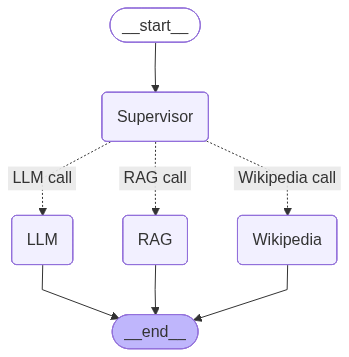

In [221]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [305]:
state={"messages": ["tell me from wikipedia about nepal?"]}
result = app.invoke(state)


Question: tell me from wikipedia about nepal?
Parsed Response: Topic='wikipedia' Reason='The user asked for information from Wikipedia.'
-> Router ->
Question: tell me from wikipedia about nepal?
-> Wikipedia call ->
Page: Follow Me! (TV programme)
Summary: Follow Me! is a series of television programmes produced by Bayerischer Rundfunk and the BBC in the late 1970s to provide a crash course in the English language. It became popular in many overseas countries as a first introduction to English; in 1983, five hundred million people watched the show in China alone, featuring Kathy Flower.
Follow Me! was also shown regularly on SBS Television in Australia between 1981 and 1985 in tandem with another English tuition program, People You Meet.
The British actor Francis Matthews hosted and narrated the series.
The course consists of sixty lessons. Each lesson lasts from 12 to 15 minutes and covers a specific lexis. The lessons follow a consistent group of actors, with the relationships betwe

In [254]:
state

{'messages': ['king of england?']}